# Student Performance Prediction Using Regression

## CSE305 - Machine Learning Fundamentals

### Mini Project 1 (CA1)

**Project Option:** Option 2 - Student Performance Prediction using Regression

**Target Variable:** GPA

---

## Project Objective

The objective of this project is to develop a regression-based Machine Learning
model to predict a student's academic performance using student-related
features.

The project demonstrates the complete Machine Learning workflow:

Data
→ Data Cleaning
→ Exploration
→ Feature Engineering
→ Regression from Scratch
→ Gradient Descent
→ Feature Scaling
→ Scikit-Learn Regression
→ Evaluation
→ Model Comparison
→ Residual Analysis
→ Conclusion

The project focuses on understanding how a real-world regression problem can
be converted into a working Machine Learning solution and how the resulting
model can be evaluated and interpreted.

The workflow above follows the exact workflow specified in your CA1 document. 

---

# 1. Project Title and Objective

## Problem Statement

Student academic performance can depend on several factors such as study time,
previous academic performance, attendance, absences, family background,
parental support, tutoring, and participation in educational activities.

In this project, a regression model is developed to predict a student's
Grade Point Average (GPA) using available student-related information.

The project also investigates the relationship between different student
features and GPA and compares a simple univariate regression model with a
multivariate regression model.

## Objectives

The main objectives of this project are:

1. Understand the Student Performance dataset.
2. Identify features and the target variable.
3. Clean and prepare the dataset.
4. Perform Exploratory Data Analysis.
5. Perform feature engineering.
6. Implement Mean Squared Error using NumPy.
7. Implement Batch Gradient Descent from scratch.
8. Experiment with different learning rates.
9. Demonstrate the effect of feature scaling.
10. Build a univariate regression model.
11. Build a multivariate Linear Regression model using Scikit-Learn.
12. Evaluate models using MAE, RMSE, and R².
13. Compare different regression models.
14. Analyse regression coefficients.
15. Perform residual analysis.
16. Discuss regression assumptions and limitations.
17. Present the final findings and conclusion.

The project-specific objectives are based on the Option 2 requirements in the assignment. 

---

# 2. Dataset Information

## Dataset Description

The Student Performance Dataset contains information related to students'
academic, demographic, and behavioural characteristics.

The dataset contains variables such as:

- Student ID
- Age
- Gender
- Ethnicity
- Parental Education
- Weekly Study Time
- Absences
- Tutoring
- Parental Support
- Extracurricular Activities
- Sports
- Music
- Volunteering
- Grade Class
- GPA

## Target Variable

The target variable selected for this project is:

**GPA**

GPA is a continuous numerical variable, making it suitable for a regression
problem.

## Source

The dataset specified for this project is the Student Performance Dataset
provided in the CA1 project instructions.


---

In [10]:

# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("All required libraries imported successfully.")

All required libraries imported successfully.


# 3. Import Required Libraries

The following Python libraries are used in this project:

### NumPy
NumPy is used for numerical calculations and for implementing Mean Squared
Error and Batch Gradient Descent from scratch.

### Pandas
Pandas is used for loading, examining, cleaning, and manipulating the dataset.

### Matplotlib
Matplotlib is used to create regression and analysis visualisations.

### Seaborn
Seaborn is used to create statistical visualisations such as scatter plots,
histograms, and correlation heatmaps.

### Scikit-Learn
Scikit-Learn is used for train-test splitting, preprocessing, Linear
Regression, and model evaluation.

---

# 4. Load Dataset

The dataset is loaded from a CSV file.

The CSV file should be placed in the same project folder as this Jupyter
Notebook.

A relative file path is used instead of an absolute file path so that the
notebook remains portable.

---

In [11]:
# Load the dataset using a relative/project-based path.
# Keep student_performance.csv in the same folder as this notebook.

DATA_PATH = "student_performance.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [12]:

# Display first five rows

df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


## Initial Dataset Inspection

The first five rows are displayed to understand the structure of the dataset,
the available variables, and the type of information recorded for each
student.

---

In [13]:

# Display dataset dimensions

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2392
Number of columns: 15


In [14]:

# Display column names

print("Column Names:")
for column in df.columns:
    print(column)


Column Names:
StudentID
Age
Gender
Ethnicity
ParentalEducation
StudyTimeWeekly
Absences
Tutoring
ParentalSupport
Extracurricular
Sports
Music
Volunteering
GPA
GradeClass


In [15]:

# Display data types and non-null information

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [16]:

# Statistical summary

df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
StudentID,2392.0,2196.500000,690.655244,1001.000000,1598.750000,2196.500000,2794.250000,3392.000000
Age,2392.0,16.468645,1.123798,15.000000,15.000000,16.000000,17.000000,18.000000
Gender,2392.0,0.510870,0.499986,0.000000,0.000000,1.000000,1.000000,1.000000
Ethnicity,2392.0,0.877508,1.028476,0.000000,0.000000,0.000000,2.000000,3.000000
ParentalEducation,2392.0,1.746237,1.000411,0.000000,1.000000,2.000000,2.000000,4.000000
StudyTimeWeekly,2392.0,9.771992,5.652774,0.001057,5.043079,9.705363,14.408410,19.978094
Absences,2392.0,14.541388,8.467417,0.000000,7.000000,15.000000,22.000000,29.000000
Tutoring,2392.0,0.301421,0.458971,0.000000,0.000000,0.000000,1.000000,1.000000
ParentalSupport,2392.0,2.122074,1.122813,0.000000,1.000000,2.000000,3.000000,4.000000
Extracurricular,2392.0,0.383361,0.486307,0.000000,0.000000,0.000000,1.000000,1.000000


# 5. Data Understanding

From the initial inspection, the dataset contains student-level observations
with numerical and categorical variables.

The target variable for this project is GPA.

Before building a regression model, the dataset must be checked for:

- Missing values
- Duplicate records
- Incorrect data types
- Unusual or invalid values
- Numerical variables
- Categorical variables

The StudentID column, if present, is treated as an identifier rather than a
predictive feature because it does not contain meaningful information about
student performance.

This matches the required data-understanding checks and the instruction to remove irrelevant identifiers.  

---

# 6. Data Cleaning

Data cleaning is performed before Machine Learning model development.

The following checks will be performed:

1. Missing values
2. Duplicate records
3. Data types
4. Unusual values
5. Numerical and categorical columns

The cleaning decisions will be based on the actual condition of the dataset.

---

In [17]:

# Check missing values

missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


In [18]:

# Check duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [19]:

# Display data types

print(df.dtypes)

StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object


## Numerical and Categorical Columns

Numerical variables contain numerical measurements and can be directly used
after suitable preprocessing.

Categorical variables contain categories such as gender, tutoring status,
parental support, and participation in activities.

Categorical variables cannot be directly supplied to a standard Linear
Regression model in text form, so they will later be converted using
One-Hot Encoding.

---

In [20]:

# Identify numerical and categorical columns

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass']

Categorical Columns:
[]


## Handling Missing Values

Missing values can prevent Machine Learning algorithms from processing the
dataset correctly.

For numerical variables, the median is used because it is less sensitive to
extreme values than the mean.

For categorical variables, the most frequently occurring category (mode) is
used.

---

In [21]:

# Handle missing values

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

print("Missing values handled successfully.")

Missing values handled successfully.


In [22]:

# Verify missing values after treatment

print(df.isnull().sum())

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


## Removing Duplicate Records

Duplicate records can cause the same observation to receive unnecessary
importance during model training.

Therefore, duplicate records are removed where they are present.

---

In [23]:

# Record dataset size before duplicate removal

rows_before = len(df)

# Remove duplicates
df = df.drop_duplicates()

rows_after_duplicates = len(df)

print("Rows before duplicate removal:", rows_before)
print("Rows after duplicate removal :", rows_after_duplicates)

Rows before duplicate removal: 2392
Rows after duplicate removal : 2392


# Outlier Analysis

Outliers are observations that are unusually high or low compared with the
remaining observations.

For numerical variables, potential outliers are identified using the
Interquartile Range (IQR) method.

IQR = Q3 - Q1

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

The purpose of this step is to identify unusual observations. A potential
outlier is not automatically removed because an extreme value may still
represent a valid student observation.


---

In [24]:

# Identify potential numerical outliers using IQR

numeric_cols = df.select_dtypes(include=np.number).columns

outlier_summary = []

for column in numeric_cols:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_summary.append(
        [column, Q1, Q3, IQR, lower_bound, upper_bound, count]
    )

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=[
        "Feature",
        "Q1",
        "Q3",
        "IQR",
        "Lower Bound",
        "Upper Bound",
        "Potential Outliers"
    ]
)

outlier_df


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers
0,StudentID,1598.750000,2794.250000,1195.500000,-194.500000,4587.500000,0
1,Age,15.000000,17.000000,2.000000,12.000000,20.000000,0
2,Gender,0.000000,1.000000,1.000000,-1.500000,2.500000,0
3,Ethnicity,0.000000,2.000000,2.000000,-3.000000,5.000000,0
4,ParentalEducation,1.000000,2.000000,1.000000,-0.500000,3.500000,120
5,StudyTimeWeekly,5.043079,14.408410,9.365330,-9.004916,28.456405,0
6,Absences,7.000000,22.000000,15.000000,-15.500000,44.500000,0
7,Tutoring,0.000000,1.000000,1.000000,-1.500000,2.500000,0
8,ParentalSupport,1.000000,3.000000,2.000000,-2.000000,6.000000,0
9,Extracurricular,0.000000,1.000000,1.000000,-1.500000,2.500000,0


## Data Cleaning Decision

Potential outliers identified by the IQR method are reviewed rather than
automatically deleted.

The project does not remove valid student records simply because they are
statistically unusual.

This prevents the unnecessary loss of information from the dataset.

---

In [25]:

# Final dataset size

rows_after = len(df)
rows_removed = rows_before - rows_after

print("Dataset Cleaning Summary")
print("------------------------")
print("Rows before cleaning :", rows_before)
print("Rows after cleaning  :", rows_after)
print("Rows removed         :", rows_removed)

Dataset Cleaning Summary
------------------------
Rows before cleaning : 2392
Rows after cleaning  : 2392
Rows removed         : 0


# 7. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the relationships
between student characteristics and GPA.


1. One numerical feature versus target plot.
2. One additional meaningful plot.
3. At least two observations from EDA.

The analysis below focuses on study time, absences, GPA, and other available
student characteristics.

---

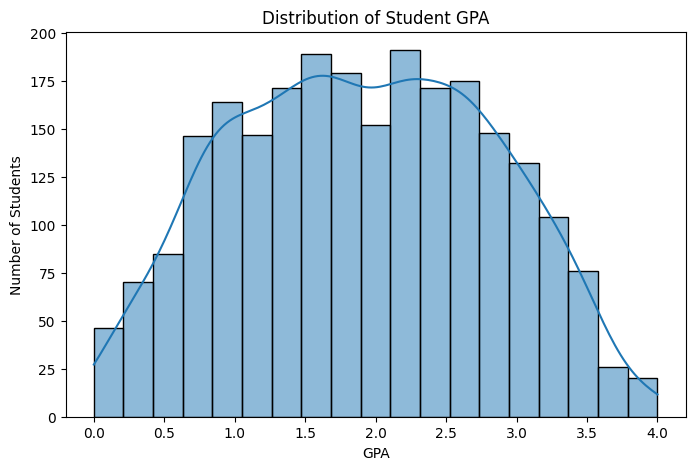

In [26]:

# Distribution of GPA

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="GPA",
    kde=True
)

plt.title("Distribution of Student GPA")
plt.xlabel("GPA")
plt.ylabel("Number of Students")

plt.show()

## GPA Distribution Observation

The histogram shows the distribution of GPA values across the students in
the dataset.

The concentration and spread of GPA values help us understand whether the
target variable contains a wide range of academic performance.

The exact observation should be based on the resulting graph.

---

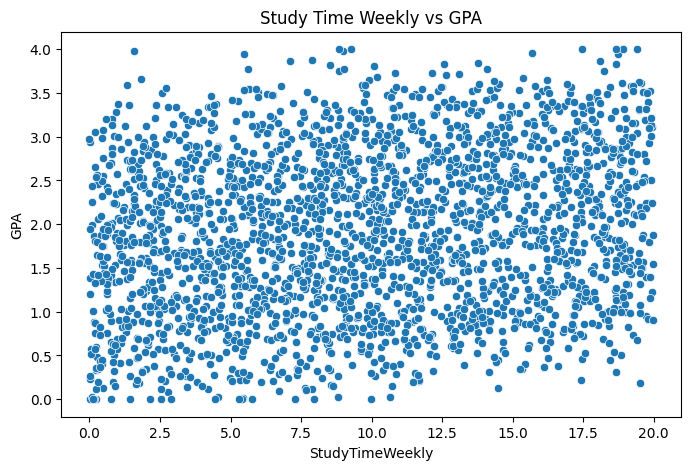

In [27]:
# EDA Plot 1: Study Time vs GPA
study_col = "StudyTimeWeekly" if "StudyTimeWeekly" in df.columns else next(
    (c for c in df.columns if "study" in c.lower() and "time" in c.lower()), None
)
if study_col is None or "GPA" not in df.columns:
    raise KeyError("The dataset must contain a GPA column and a weekly study-time column.")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x=study_col, y="GPA")
plt.title("Study Time Weekly vs GPA")
plt.xlabel(study_col)
plt.ylabel("GPA")
plt.show()

## EDA Observation 1

The scatter plot examines the relationship between weekly study time and GPA.

If the points show an upward tendency, students with greater weekly study
time tend to have higher GPA values in this dataset.

If the points are widely scattered, the relationship is weaker.

This observation represents an association in the dataset and does not prove
that increasing study time directly causes an increase in GPA.

---

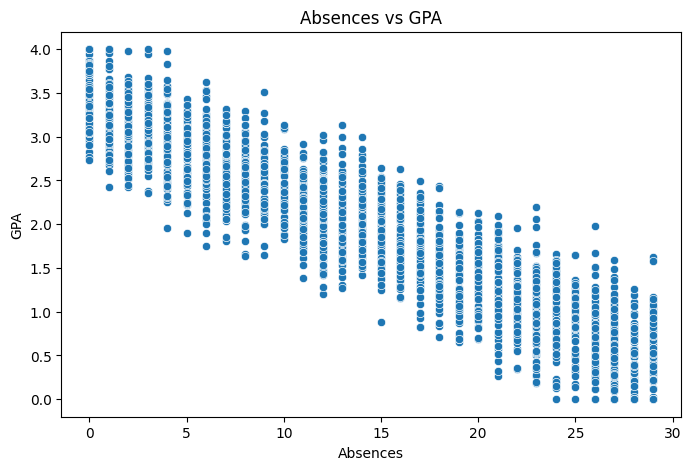

In [28]:
# EDA Plot 2: Absences vs GPA
absence_col = "Absences" if "Absences" in df.columns else next(
    (c for c in df.columns if "absence" in c.lower()), None
)
if absence_col is None or "GPA" not in df.columns:
    raise KeyError("The dataset must contain a GPA column and an absences column.")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x=absence_col, y="GPA")
plt.title("Absences vs GPA")
plt.xlabel(absence_col)
plt.ylabel("GPA")
plt.show()

## EDA Observation 2

The scatter plot examines the relationship between the number of absences and
GPA.

The distribution of points can be used to determine whether GPA generally
changes as absences increase.

This relationship should be interpreted as an association rather than proof
of causation.

---

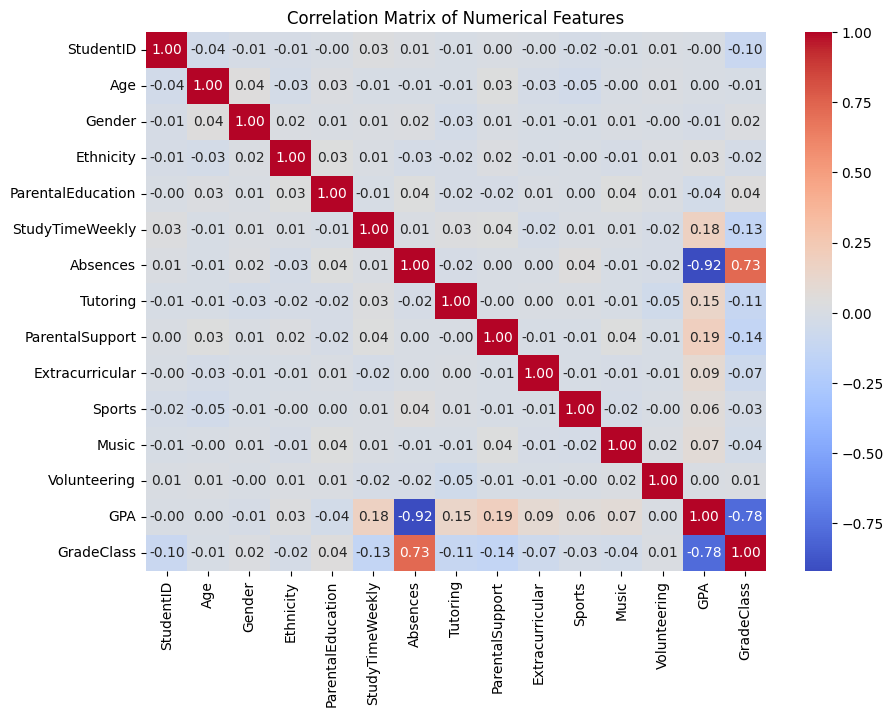

In [29]:

# Correlation matrix

correlation_matrix = df.select_dtypes(
    include=np.number
).corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

In [30]:

# Correlation of numerical features with GPA

gpa_correlations = (
    correlation_matrix["GPA"]
    .sort_values(ascending=False)
)

gpa_correlations

GPA                  1.000000
ParentalSupport      0.190774
StudyTimeWeekly      0.179275
Tutoring             0.145119
Extracurricular      0.094078
Music                0.073318
Sports               0.057859
Ethnicity            0.027760
Volunteering         0.003258
Age                  0.000275
StudentID           -0.002697
Gender              -0.013360
ParentalEducation   -0.035854
GradeClass          -0.782835
Absences            -0.919314
Name: GPA, dtype: float64

## EDA Summary

The EDA stage helps identify numerical variables that may be useful for
predicting GPA.

StudyTimeWeekly is selected for the univariate regression because it is a
meaningful numerical student-related feature and provides a clear example
of using one feature to predict academic performance.

Other numerical and categorical variables will be considered for the
multivariate model.

The EDA findings describe relationships in the dataset and should not be
interpreted as causal conclusions.

---

# 8. Feature Selection and Feature Engineering

Feature selection means choosing variables that are potentially useful for
predicting the target.

The StudentID variable is an identifier and is therefore excluded from model
training.

For the univariate model, StudyTimeWeekly is selected as the single numerical
feature.

For the multivariate model, useful numerical and categorical variables are
considered.

Feature engineering is also demonstrated by converting weekly study time
into meaningful study-time categories.

---

In [31]:
# Feature Engineering:
# Convert weekly study time into categories

study_col = "StudyTimeWeekly" if "StudyTimeWeekly" in df.columns else next(
    (c for c in df.columns if "study" in c.lower() and "time" in c.lower()), None
)
if study_col is None:
    raise KeyError("A weekly study-time column is required for feature engineering.")

df["StudyTimeCategory"] = pd.cut(
    df[study_col],
    bins=[-np.inf, 5, 10, 20, np.inf],
    labels=["Low", "Moderate", "High", "Very High"]
)

df[[study_col, "StudyTimeCategory", "GPA"]].head()

,StudyTimeWeekly,StudyTimeCategory,GPA
0,19.833723,High,2.929196
1,15.408756,High,3.042915
2,4.210570,Low,0.112602
3,10.028829,High,2.054218
4,4.672495,Low,1.288061


## Feature Engineering Explanation

StudyTimeWeekly is a continuous numerical variable.

A StudyTimeCategory feature is created to group students into four study-time
categories:

- Low
- Moderate
- High
- Very High

This engineered categorical feature can help investigate whether study-time
categories provide additional information when categorical variables are
included in the multivariate model.

---

# 9. Univariate Linear Regression from Scratch

Univariate Linear Regression uses one numerical feature to predict a
continuous target.

For this project:

**Input Feature:** StudyTimeWeekly

**Target:** GPA

The linear regression equation is:

ŷ = θ₀ + θ₁X

where:

θ₀ = intercept

θ₁ = slope

X = input feature

ŷ = predicted GPA

The model parameters will be learned using Batch Gradient Descent.

---

In [32]:
# Prepare univariate data

study_col = "StudyTimeWeekly" if "StudyTimeWeekly" in df.columns else next(
    (c for c in df.columns if "study" in c.lower() and "time" in c.lower()), None
)
if study_col is None:
    raise KeyError("A weekly study-time column is required for univariate regression.")

X_uni = df[[study_col]].values
y = df["GPA"].values

print("Univariate feature:", study_col)
print("X shape:", X_uni.shape)
print("y shape:", y.shape)

Univariate feature: StudyTimeWeekly
X shape: (2392, 1)
y shape: (2392,)


# 10. Train-Test Split for Univariate Regression

The data is divided into:

- 80% training data
- 20% testing data

The training data is used to learn the model parameters.

The testing data is kept separate and is used to evaluate the model on unseen
observations.

A fixed random_state is used so that the experiment can be reproduced.

---

In [33]:

# Train-test split

X_train_uni, X_test_uni, y_train_uni, y_test_uni = train_test_split(
    X_uni,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train_uni))
print("Testing samples :", len(X_test_uni))

Training samples: 1913
Testing samples : 479


# 11. MSE Cost Function

Mean Squared Error (MSE) is used as the cost function for the
from-scratch regression model.

The formula is:

MSE = (1/n) × Σ(y - ŷ)²

where:

y = actual target

ŷ = predicted target

n = number of observations

A lower MSE indicates that predictions are closer to the actual values.

The MSE function is implemented manually using NumPy.


---

In [34]:

def mse_cost(X, y, theta):
    """
    Calculate Mean Squared Error using NumPy.
    """

    predictions = X @ theta

    errors = predictions - y

    mse = np.mean(errors ** 2)

    return mse

# 12. Batch Gradient Descent

Gradient Descent is an optimization algorithm used to minimize the cost
function.

Batch Gradient Descent calculates the gradient using the complete training
dataset at every iteration.

The parameters are updated using:

θ = θ - α × gradient

where:

θ = model parameters

α = learning rate

gradient = direction of the cost function

The Gradient Descent function below returns:

1. Final model parameters
2. Cost history for every iteration

---

In [35]:

def batch_gradient_descent(
    X,
    y,
    learning_rate,
    n_iterations
):
    """
    Batch Gradient Descent for Linear Regression.
    """

    m = len(y)

    # Initialize parameters with zeros
    theta = np.zeros(X.shape[1])

    cost_history = []

    for iteration in range(n_iterations):

        # Predictions
        predictions = X @ theta

        # Error
        errors = predictions - y

        # Gradient
        gradients = (2 / m) * (X.T @ errors)

        # Update parameters
        theta = theta - learning_rate * gradients

        # Calculate and store cost
        cost = mse_cost(X, y, theta)

        cost_history.append(cost)

    return theta, cost_history

# 13. Add Intercept Term

The Linear Regression equation contains an intercept:

ŷ = θ₀ + θ₁X

To calculate this using matrix multiplication, a column containing ones is
added to the feature matrix.

The first parameter represents the intercept and the second parameter
represents the slope.

---

In [36]:

# Add intercept column

X_train_b = np.c_[
    np.ones((X_train_uni.shape[0], 1)),
    X_train_uni
]

X_test_b = np.c_[
    np.ones((X_test_uni.shape[0], 1)),
    X_test_uni
]

print("Training matrix shape:", X_train_b.shape)
print("Testing matrix shape :", X_test_b.shape)

Training matrix shape: (1913, 2)
Testing matrix shape : (479, 2)


# 14. Learning Rate Experiment

The learning rate controls how large each parameter update is during Gradient
Descent.

Three different learning rates are tested.

The purpose is to understand:

- Which learning rate converges well.
- Which learning rate converges slowly.
- Whether any learning rate becomes unstable or diverges.

This is directly required in Task 2. 

---

In [37]:

# Learning rate experiment

learning_rates = [
    0.0001,
    0.001,
    0.01
]

n_iterations = 1000

learning_rate_results = {}

for lr in learning_rates:

    theta, cost_history = batch_gradient_descent(
        X_train_b,
        y_train_uni,
        learning_rate=lr,
        n_iterations=n_iterations
    )

    learning_rate_results[lr] = {
        "theta": theta,
        "cost_history": cost_history
    }

    print("Learning Rate:", lr)
    print("Final Theta:", theta)
    print("Final Cost:", cost_history[-1])
    print()

Learning Rate: 0.0001
Final Theta: [0.09000026 0.14662884]
Final Cost: 1.386251628034848

Learning Rate: 0.001
Final Theta: [0.64184764 0.10436378]
Final Cost: 1.0401077806052785

Learning Rate: 0.01
Final Theta: [-5.93800822e+192 -7.75315181e+193]
Final Cost: inf



# 15. Learning Rate Cost Curves

The following graph compares the cost function over iterations for the three
learning rates.

A decreasing curve indicates that Gradient Descent is reducing the cost.

A curve that decreases very slowly indicates slow convergence.

A curve that oscillates or increases may indicate that the learning rate is
too large.

---

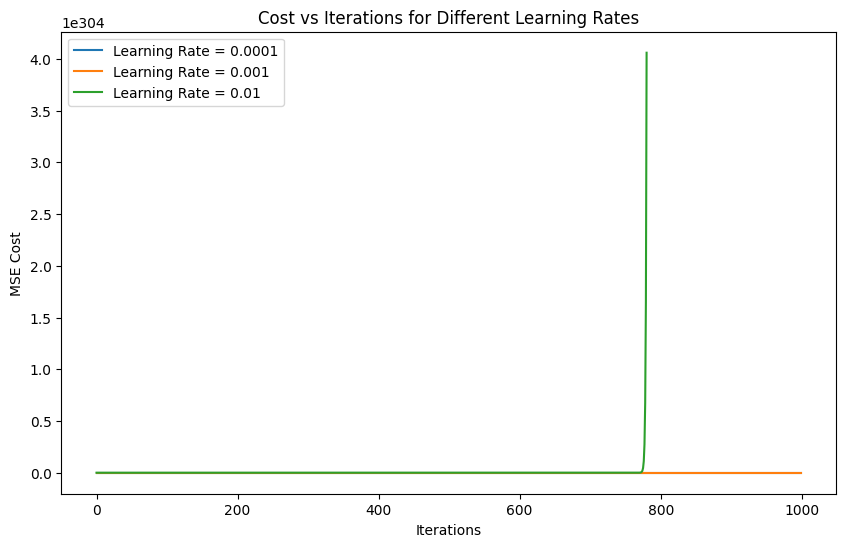

In [38]:

plt.figure(figsize=(10, 6))

for lr in learning_rates:

    plt.plot(
        learning_rate_results[lr]["cost_history"],
        label=f"Learning Rate = {lr}"
    )

plt.title("Cost vs Iterations for Different Learning Rates")
plt.xlabel("Iterations")
plt.ylabel("MSE Cost")
plt.legend()

plt.show()

## Learning Rate Analysis

The learning-rate curves are compared based on their convergence behaviour.

The learning rate that reaches a low cost smoothly and efficiently is
considered the most suitable among the tested values.

The smallest learning rate is expected to make smaller parameter updates and
therefore may converge more slowly.

A very large learning rate can produce unstable behaviour.

The final conclusion should be based on the actual curves generated by the
notebook.

---

# 16. Feature Scaling

Feature scaling transforms numerical features into a comparable numerical
range.

Standardisation is performed using:

z = (x - μ) / σ

where:

μ = mean of the feature

σ = standard deviation of the feature

Feature scaling is especially useful for Gradient Descent because it can
make optimization more efficient and reduce problems caused by features
having very different numerical scales.


---

In [39]:

# Standardize StudyTimeWeekly

scaler_uni = StandardScaler()

X_train_scaled = scaler_uni.fit_transform(
    X_train_uni
)

X_test_scaled = scaler_uni.transform(
    X_test_uni
)

# Add intercept
X_train_scaled_b = np.c_[
    np.ones((X_train_scaled.shape[0], 1)),
    X_train_scaled
]

X_test_scaled_b = np.c_[
    np.ones((X_test_scaled.shape[0], 1)),
    X_test_scaled
]

print("Feature scaling completed.")

Feature scaling completed.


# 17. Gradient Descent Using Scaled Feature

Gradient Descent is now executed again using the standardized
StudyTimeWeekly feature.

A learning rate of 0.01 is used for this experiment.

The cost history will be compared with the unscaled version.

---

In [40]:

# Gradient Descent using scaled feature

theta_scaled, cost_scaled = batch_gradient_descent(
    X_train_scaled_b,
    y_train_uni,
    learning_rate=0.01,
    n_iterations=1000
)

print("Scaled Feature Theta:")
print(theta_scaled)

print("\nFinal Scaled Cost:")
print(cost_scaled[-1])

Scaled Feature Theta:
[1.90111935 0.17816941]

Final Scaled Cost:
0.8078483647658741


# 18. Scaled vs Unscaled Gradient Descent

The next graph compares the convergence behaviour of Gradient Descent before
and after feature scaling.

This comparison demonstrates why feature scaling can be important when using
Gradient Descent.

---

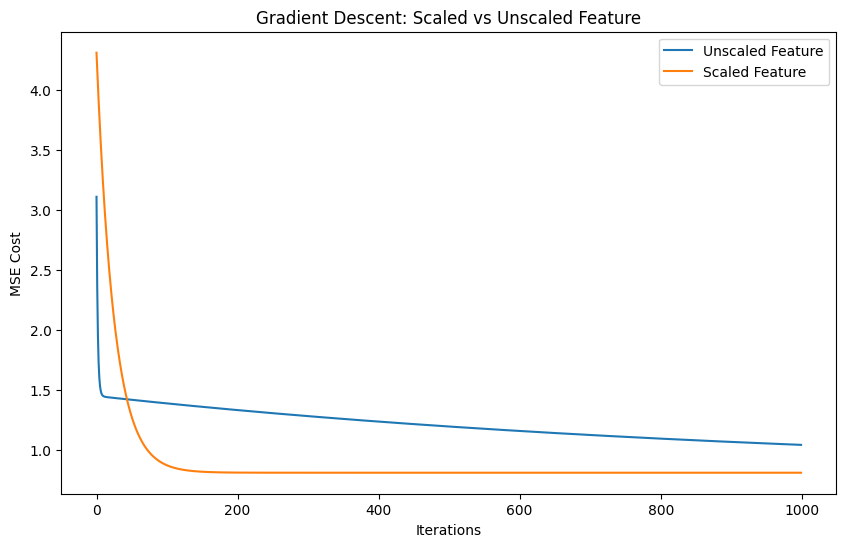

In [41]:

# Unscaled Gradient Descent

theta_unscaled, cost_unscaled = batch_gradient_descent(
    X_train_b,
    y_train_uni,
    learning_rate=0.001,
    n_iterations=1000
)

# Plot comparison

plt.figure(figsize=(10, 6))

plt.plot(
    cost_unscaled,
    label="Unscaled Feature"
)

plt.plot(
    cost_scaled,
    label="Scaled Feature"
)

plt.title("Gradient Descent: Scaled vs Unscaled Feature")
plt.xlabel("Iterations")
plt.ylabel("MSE Cost")
plt.legend()

plt.show()

## Feature Scaling Analysis

The scaled and unscaled cost curves are compared to understand the effect of
standardisation.

Feature scaling changes the numerical range of StudyTimeWeekly.

When the feature is standardized, Gradient Descent can generally make more
consistent parameter updates because the input feature is centred and placed
on a standard scale.

The actual improvement in convergence should be determined from the cost
curves produced above.

---

# 19. Final Univariate Regression from Scratch

The scaled feature is used for the final from-scratch univariate regression.

The final model parameters are obtained using Batch Gradient Descent.

---

In [42]:

# Final scratch regression

theta_final_scratch, cost_final_scratch = batch_gradient_descent(
    X_train_scaled_b,
    y_train_uni,
    learning_rate=0.01,
    n_iterations=1000
)

print("Final Theta:")
print(theta_final_scratch)

print("\nFinal Training MSE:")
print(cost_final_scratch[-1])

Final Theta:
[1.90111935 0.17816941]

Final Training MSE:
0.8078483647658741


# 20. Predictions from the Scratch Model

The learned parameters are used to predict GPA for the unseen test data.

The test data is transformed using the same scaler fitted on the training
data.

---

In [43]:

# Generate test predictions

y_pred_scratch = (
    X_test_scaled_b @ theta_final_scratch
)

print("First 10 predicted GPA values:")
print(y_pred_scratch[:10])

First 10 predicted GPA values:
[1.60071336 1.65865739 1.92737655 2.10300434 1.7082492  2.12793298
 2.04560962 1.73041166 1.97743583 1.96549652]


# 21. Evaluation of Univariate Scratch Model

The scratch model is evaluated using:

### MAE
Mean Absolute Error measures the average absolute prediction error.

### RMSE
Root Mean Squared Error is the square root of Mean Squared Error and gives
greater influence to larger errors.

### R²
R² measures the proportion of variation in GPA explained by the regression
model.

---

In [44]:

# Evaluate scratch model

mae_scratch = mean_absolute_error(
    y_test_uni,
    y_pred_scratch
)

rmse_scratch = np.sqrt(
    mean_squared_error(
        y_test_uni,
        y_pred_scratch
    )
)

r2_scratch = r2_score(
    y_test_uni,
    y_pred_scratch
)

print("Univariate Regression from Scratch")
print("----------------------------------")
print("MAE :", mae_scratch)
print("RMSE:", rmse_scratch)
print("R²  :", r2_scratch)

Univariate Regression from Scratch
----------------------------------
MAE : 0.7625682387041227
RMSE: 0.9059507376782326
R²  : 0.007480506666110998


# 22. Interpretation of the Scratch Model

The final theta values contain:

θ₀ = intercept

θ₁ = slope for the standardized StudyTimeWeekly feature.

Because the input feature was standardized, θ₁ represents the expected
change in predicted GPA associated with a one-standard-deviation increase
in weekly study time.

The coefficient represents a statistical association in the dataset and
does not prove that study time causes GPA to increase or decrease.

---

In [45]:

print("Intercept (θ0):", theta_final_scratch[0])
print("Slope (θ1):", theta_final_scratch[1])

Intercept (θ0): 1.9011193534239288
Slope (θ1): 0.1781694128212027


# 23. Univariate Regression Using Scikit-Learn

The same numerical feature, StudyTimeWeekly, is now used with Scikit-Learn's
LinearRegression.

This provides a ready-made implementation that can be compared with the
regression model implemented from scratch.

---

In [46]:

# Scikit-Learn univariate Linear Regression

sklearn_uni_model = LinearRegression()

sklearn_uni_model.fit(
    X_train_uni,
    y_train_uni
)

y_pred_sklearn_uni = sklearn_uni_model.predict(
    X_test_uni
)

print("Intercept:", sklearn_uni_model.intercept_)
print("Coefficient:", sklearn_uni_model.coef_[0])

Intercept: 1.5964706415347978
Coefficient: 0.031250810119125276


In [47]:

# Evaluate Scikit-Learn univariate model

mae_sklearn_uni = mean_absolute_error(
    y_test_uni,
    y_pred_sklearn_uni
)

rmse_sklearn_uni = np.sqrt(
    mean_squared_error(
        y_test_uni,
        y_pred_sklearn_uni
    )
)

r2_sklearn_uni = r2_score(
    y_test_uni,
    y_pred_sklearn_uni
)

print("Scikit-Learn Univariate Regression")
print("-----------------------------------")
print("MAE :", mae_sklearn_uni)
print("RMSE:", rmse_sklearn_uni)
print("R²  :", r2_sklearn_uni)

Scikit-Learn Univariate Regression
-----------------------------------
MAE : 0.7625682386160145
RMSE: 0.9059507376224073
R²  : 0.007480506788430263


# 24. Multivariate Linear Regression with Scikit-Learn

The univariate model uses only StudyTimeWeekly.

However, student performance may be associated with multiple characteristics.

Therefore, a multivariate Linear Regression model is developed using multiple
numerical and categorical features.

The model will:

1. Select useful features.
2. Remove the StudentID identifier.
3. Separate numerical and categorical variables.
4. Standardize numerical features.
5. One-hot encode categorical variables.
6. Split the data into 80% training and 20% testing data.
7. Train Linear Regression using Scikit-Learn.


---

In [48]:
# Create a copy for multivariate modelling
df_model = df.copy()

# Remove identifier column if it exists
identifier_candidates = [c for c in ["StudentID", "StudentId", "student_id", "Student ID"] if c in df_model.columns]
if identifier_candidates:
    df_model = df_model.drop(columns=identifier_candidates)

print(df_model.columns.tolist())

['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass', 'StudyTimeCategory']


# 25. Define Features and Target

The target variable is GPA.

All other selected variables are candidate features.

The StudentID column is excluded because it is an identifier and does not
represent meaningful predictive information.

---

In [49]:

# Define target and features

target = "GPA"

X = df_model.drop(columns=[target])
y = df_model[target]

print("Target:", target)

print("\nFeatures:")
print(X.columns.tolist())

Target: GPA

Features:
['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GradeClass', 'StudyTimeCategory']


In [50]:

# Identify numerical and categorical features

numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GradeClass']

Categorical Features:
['StudyTimeCategory']


# 26. Train-Test Split

The dataset is divided into:

**80% Training Data**

**20% Testing Data**

The training set is used to train the regression model.

The test set is used only after training to evaluate the model's performance
on unseen observations.

A fixed random_state of 42 is used for reproducibility.

---

In [51]:

# 80/20 train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape :", X_test.shape)

Training data shape: (1913, 14)
Testing data shape : (479, 14)


# 27. Categorical Encoding and Feature Scaling

Linear Regression requires numerical input.

Therefore:

### Numerical Features

Numerical features are standardized using StandardScaler.

### Categorical Features

Categorical features are converted into binary indicator columns using
One-Hot Encoding.

`handle_unknown="ignore"` ensures that an unseen category in the test data
does not cause an encoding error.

---

In [52]:

# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


# 28. Transform the Dataset

The preprocessing pipeline is fitted only on the training data.

The same transformations are then applied to the test data.

This prevents information from the test set from influencing the training
process.

---

In [53]:

# Fit preprocessing on training data

X_train_processed = preprocessor.fit_transform(
    X_train
)

# Transform test data

X_test_processed = preprocessor.transform(
    X_test
)

print("Processed training shape:",
      X_train_processed.shape)

print("Processed testing shape:",
      X_test_processed.shape)

Processed training shape: (1913, 15)
Processed testing shape: (479, 15)


# 29. Train Multivariate Linear Regression Model

The processed numerical and categorical features are supplied to Scikit-Learn
LinearRegression.

The model learns coefficients for the selected features and uses them to
predict GPA.

---

In [54]:

# Create and train the model

multivariate_model = LinearRegression()

multivariate_model.fit(
    X_train_processed,
    y_train
)

print("Multivariate Linear Regression trained successfully.")


Multivariate Linear Regression trained successfully.


# 30. Generate Predictions

The trained model is used to generate GPA predictions for the test dataset.

These predictions are compared with the actual GPA values during model
evaluation.

---

In [55]:

# Generate test predictions

y_pred_multi = multivariate_model.predict(
    X_test_processed
)

print("First 10 predictions:")
print(y_pred_multi[:10])


First 10 predictions:
[1.45343659 2.97408668 1.8333031  3.59936398 0.29344788 2.7211769
 1.64605277 2.29656252 2.10753921 1.01189887]


# 31. Model Evaluation

The multivariate model is evaluated using:

## Mean Absolute Error (MAE)

MAE represents the average absolute difference between actual and predicted
GPA values.

## Root Mean Squared Error (RMSE)

RMSE represents the square root of the average squared prediction error.

## R² Score

R² represents the proportion of variation in GPA explained by the regression
model.

All final metrics are calculated using the test dataset.


---

In [56]:

# Calculate evaluation metrics

mae_multi = mean_absolute_error(
    y_test,
    y_pred_multi
)

rmse_multi = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_multi
    )
)

r2_multi = r2_score(
    y_test,
    y_pred_multi
)

print("Multivariate Linear Regression")
print("-------------------------------")
print("MAE :", mae_multi)
print("RMSE:", rmse_multi)
print("R²  :", r2_multi)


Multivariate Linear Regression
-------------------------------
MAE : 0.15091794473346265
RMSE: 0.18914746747776978
R²  : 0.9567355745242204


In [57]:

# Evaluation table

evaluation_table = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²"
    ],
    
    "Test Score": [
        mae_multi,
        rmse_multi,
        r2_multi
    ]
})

evaluation_table


,Metric,Test Score
0,MAE,0.150918
1,RMSE,0.189147
2,R²,0.956736


# 32. Coefficient Analysis

Regression coefficients indicate the direction and magnitude of the
relationship between a feature and predicted GPA while holding the other
model features constant.

A positive coefficient indicates a positive association with predicted GPA.

A negative coefficient indicates a negative association with predicted GPA.

For categorical variables, coefficients are interpreted relative to their
reference category created during One-Hot Encoding.

Coefficient values should be interpreted carefully because feature scaling
and categorical encoding affect their numerical values.

A coefficient does not establish causation.

---

In [58]:

# Obtain processed feature names

feature_names = preprocessor.get_feature_names_out()

coefficients = multivariate_model.coef_

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df["AbsoluteCoefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "Coefficient"
)

coefficient_df


,Feature,Coefficient,AbsoluteCoefficient
5,numerical__Absences,-0.789155,0.789155
12,numerical__GradeClass,-0.075737,0.075737
0,numerical__Age,-0.006479,0.006479
11,numerical__Volunteering,0.000022,0.000022
3,numerical__ParentalEducation,0.001269,0.001269
2,numerical__Ethnicity,0.003671,0.003671
1,numerical__Gender,0.006554,0.006554
14,categorical__StudyTimeCategory_Moderate,0.016412,0.016412
13,categorical__StudyTimeCategory_Low,0.019391,0.019391
10,numerical__Music,0.058461,0.058461


# 33. Five Smallest Coefficients

The five smallest coefficients represent the strongest negative coefficient
values in the fitted model.

They are displayed below for interpretation.

---

In [59]:

five_smallest = coefficient_df.head(5)

five_smallest


,Feature,Coefficient,AbsoluteCoefficient
5,numerical__Absences,-0.789155,0.789155
12,numerical__GradeClass,-0.075737,0.075737
0,numerical__Age,-0.006479,0.006479
11,numerical__Volunteering,0.000022,0.000022
3,numerical__ParentalEducation,0.001269,0.001269


# 34. Five Largest Coefficients

The five largest coefficients represent the strongest positive coefficient
values in the fitted model.

They are displayed below for interpretation.

---

In [60]:

five_largest = coefficient_df.tail(5).sort_values(
    "Coefficient",
    ascending=False
)

five_largest


,Feature,Coefficient,AbsoluteCoefficient
4,numerical__StudyTimeWeekly,0.163833,0.163833
7,numerical__ParentalSupport,0.155651,0.155651
6,numerical__Tutoring,0.110849,0.110849
8,numerical__Extracurricular,0.086300,0.086300
9,numerical__Sports,0.081412,0.081412


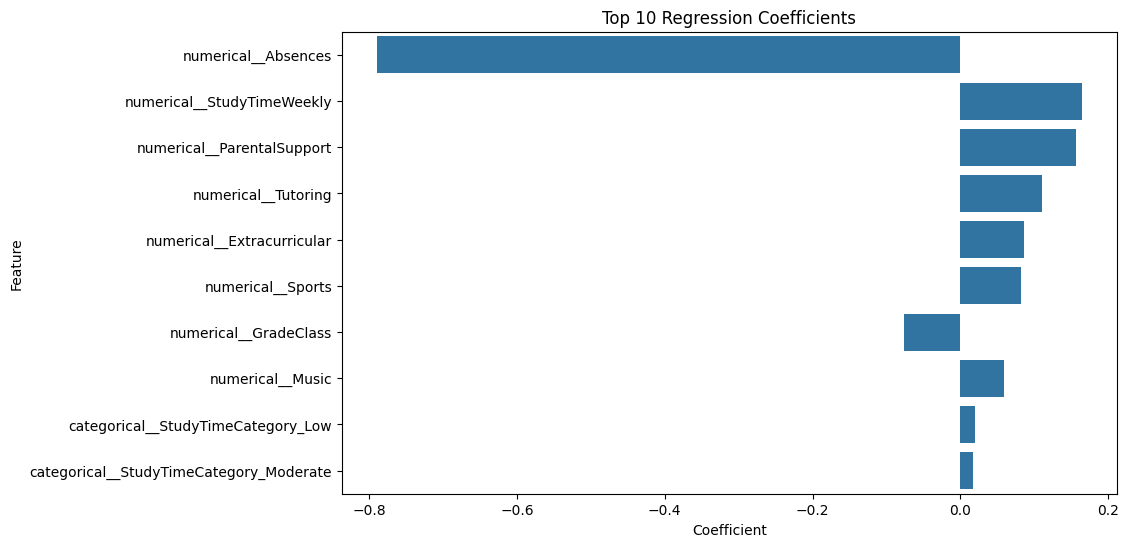

In [61]:

# Plot the 10 coefficients with the largest absolute magnitude

top_coefficients = (
    coefficient_df
    .sort_values(
        "AbsoluteCoefficient",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()


# 35. Interpretation of Three Coefficients

The three coefficients with the most meaningful interpretation should be
discussed using the actual coefficient values produced by the model.

### Coefficient 1

Feature: ____________________

Coefficient: ____________________

Interpretation:
A one-unit increase in this numerical feature is associated with an
approximately __________ change in predicted GPA, while keeping the other
included features constant.

### Coefficient 2

Feature: ____________________

Coefficient: ____________________

Interpretation:
This coefficient indicates that ________________________________.

### Coefficient 3

Feature: ____________________

Coefficient: ____________________

Interpretation:
This coefficient indicates that ________________________________.

These interpretations describe statistical associations and should not be
treated as proof of causation.

This satisfies the assignment's requirement to interpret at least three coefficients while ensuring you don't fabricate values before running the notebook. 

---

# 36. Model Comparison

Three models are compared:

### Model 1
Univariate Linear Regression implemented from scratch using NumPy.

Feature:
StudyTimeWeekly

### Model 2
Univariate Linear Regression using Scikit-Learn.

Feature:
StudyTimeWeekly

### Model 3
Multivariate Linear Regression using Scikit-Learn.

Features:
Multiple numerical and categorical features.

The comparison is based on the test-set RMSE and R².

---

In [62]:

# Create model comparison table

comparison_table = pd.DataFrame({
    "Model": [
        "Univariate - Scratch",
        "Univariate - Scikit-Learn",
        "Multivariate - Scikit-Learn"
    ],
    
    "Features Used": [
        "StudyTimeWeekly",
        "StudyTimeWeekly",
        "Multiple numerical + categorical features"
    ],
    
    "Test RMSE": [
        rmse_scratch,
        rmse_sklearn_uni,
        rmse_multi
    ],
    
    "Test R²": [
        r2_scratch,
        r2_sklearn_uni,
        r2_multi
    ]
})

comparison_table


,Model,Features Used,Test RMSE,Test R²
0,Univariate - Scratch,StudyTimeWeekly,0.905951,0.007481
1,Univariate - Scikit-Learn,StudyTimeWeekly,0.905951,0.007481
2,Multivariate - Scikit-Learn,Multiple numerical + categorical features,0.189147,0.956736


# 37. Model Comparison Analysis

The models are compared using their performance on unseen test data.

A lower RMSE indicates lower prediction error.

A higher R² indicates that a greater proportion of the variation in GPA is
explained by the model.

The best model should therefore be identified using the combination of
test-set RMSE and R² rather than training performance.

The results below are based on the actual values obtained after executing
the notebook.

---

In [63]:

# Identify model with lowest test RMSE

best_model_index = comparison_table["Test RMSE"].idxmin()

best_model = comparison_table.loc[
    best_model_index,
    "Model"
]

print("Best model based on lowest Test RMSE:")
print(best_model)


Best model based on lowest Test RMSE:
Multivariate - Scikit-Learn


## Required 2–3 Sentence Model Comparison

The model with the lowest test RMSE is ______________________________.

Adding multiple features ______________________________ the prediction
performance compared with the univariate model.

The multivariate model may perform better because it can use information
from multiple student-related characteristics instead of relying on only
one numerical feature.


---

# 38. Feature Contribution Analysis

Adding more features does not automatically guarantee better prediction
performance.

Therefore, two multivariate models are compared.

## Model A

Uses the main numerical features only.

## Model B

Uses numerical features plus useful categorical features.

The models are compared using:

- Test RMSE
- Test R²


---

In [64]:
# Model A: Numerical features only
X_num = df_model.select_dtypes(include=np.number).drop(columns=["GPA"])

X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(
    X_num, y, test_size=0.20, random_state=42
)

num_scaler = StandardScaler()
X_train_num_scaled = num_scaler.fit_transform(X_train_num)
X_test_num_scaled = num_scaler.transform(X_test_num)

model_A = LinearRegression()
model_A.fit(X_train_num_scaled, y_train_num)

pred_A = model_A.predict(X_test_num_scaled)

rmse_A = np.sqrt(mean_squared_error(y_test_num, pred_A))
r2_A = r2_score(y_test_num, pred_A)

print("Model A - Numerical Features Only")
print("RMSE:", rmse_A)
print("R²:", r2_A)

Model A - Numerical Features Only
RMSE: 0.18893459361409098
R²: 0.9568329026350805


# 39. Model B: Numerical + Categorical Features

Model B uses the full selected multivariate feature set containing numerical
and categorical variables.

The results from the previously trained multivariate model are used.

---

In [65]:

# Model B results

rmse_B = rmse_multi
r2_B = r2_multi

print("Model B - Numerical + Categorical Features")
print("RMSE:", rmse_B)
print("R²:", r2_B)


Model B - Numerical + Categorical Features
RMSE: 0.18914746747776978
R²: 0.9567355745242204


In [66]:

# Feature contribution comparison

feature_contribution = pd.DataFrame({
    "Model": [
        "Model A - Numerical Features",
        "Model B - Numerical + Categorical"
    ],
    
    "Test RMSE": [
        rmse_A,
        rmse_B
    ],
    
    "Test R²": [
        r2_A,
        r2_B
    ]
})

feature_contribution


,Model,Test RMSE,Test R²
0,Model A - Numerical Features,0.188935,0.956833
1,Model B - Numerical + Categorical,0.189147,0.956736


# 40. Feature Contribution Analysis

The results of Model A and Model B are compared.

If Model B has a lower RMSE and a higher R² than Model A, adding categorical
information contributed meaningfully to the model.

If the difference is small, categorical features provided limited additional
predictive information.

The conclusion should be based on the actual test-set results.

### Conclusion

Categorical features ______________________________ the model performance.

The RMSE changed from __________ to __________.

The R² changed from __________ to __________.

Therefore, categorical information ______________________________.

---

# 41. Residual Analysis

Residual analysis is used to understand the errors produced by the final
multivariate regression model.

The residual is calculated as:

Residual = Actual Target - Predicted Target

For this project:

Residual = Actual GPA - Predicted GPA

A residual close to zero indicates that the prediction is close to the actual
GPA.

The residual plots help identify patterns that may indicate problems with
the Linear Regression assumptions.

The residual definition and required analysis are specified in Task 6. 

---

In [67]:

# Calculate residuals

residuals = y_test - y_pred_multi

print("First 10 residuals:")
print(residuals.head(10))


First 10 residuals:
1004   -0.025712
196     0.143268
2342    0.204465
1708   -0.050843
435    -0.044471
321    -0.093483
1472    0.411326
1703   -0.048225
900     0.087167
1057   -0.253716
Name: GPA, dtype: float64


# 42. Residual vs Predicted Plot

A residual-versus-predicted plot is created with:

X-axis → Predicted GPA

Y-axis → Residuals

A horizontal reference line at residual = 0 is added.

Ideally, residuals should be distributed randomly around zero without a
strong systematic pattern.

---

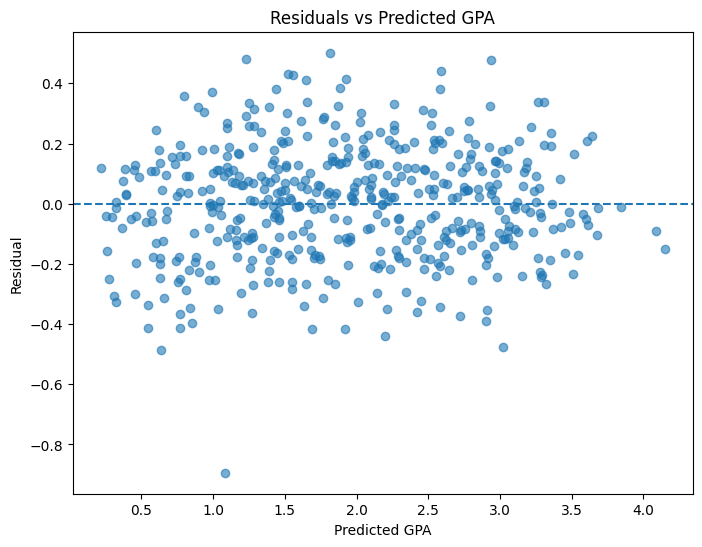

In [68]:

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_multi,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residuals vs Predicted GPA")
plt.xlabel("Predicted GPA")
plt.ylabel("Residual")

plt.show()


## Residual Plot Observation

The residual plot is examined for patterns such as:

- Increasing spread
- Decreasing spread
- Systematic over-prediction
- Systematic under-prediction
- Outliers
- Curved patterns
- Clustering

### Actual Observation

The residual plot shows ______________________________________________.

This suggests that ______________________________________________.

---

# 43. Residual Histogram

A histogram of residuals is used to examine the distribution of model errors.

A distribution that is approximately symmetric and centred around zero is
generally more consistent with the assumptions of Linear Regression.

Strong skewness or extreme residuals may indicate that the model errors are
not normally distributed.

---

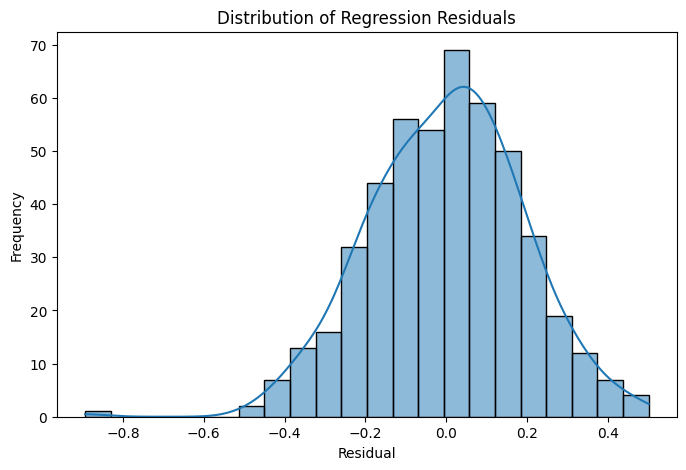

In [69]:

plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Distribution of Regression Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()


In [70]:

# Residual statistics

print("Residual Mean:", residuals.mean())
print("Residual Standard Deviation:", residuals.std())
print("Minimum Residual:", residuals.min())
print("Maximum Residual:", residuals.max())


Residual Mean: -0.0004938720436386312
Residual Standard Deviation: 0.1893445716701339
Minimum Residual: -0.8939009757640126
Maximum Residual: 0.5018705667363694


# 44. Residual Distribution Analysis

The residual histogram is examined to determine:

1. Whether the residuals are approximately normally distributed.
2. Whether the distribution is skewed.
3. Whether there are unusual extreme residuals.

### Actual Observation

The residual distribution appears __________________________________.

The distribution is __________________________________ skewed.

The residual values contain __________________________________ extreme
observations.

---

# 45. Regression Assumption Analysis

Linear Regression makes several assumptions about the relationship between
features, target values, and residuals.

The most important assumptions considered in this project are:

- Linearity
- Constant variance of residuals
- Approximate normality of residuals
- Random distribution of errors

The residual plot and residual histogram are used to assess these assumptions.

### Required Discussion

The residual plot shows ______________________________________________.

The most clearly affected assumption appears to be
______________________________________________.

The evidence for this is ______________________________________________.

This violation means ______________________________________________.

It may affect model reliability because
______________________________________________.

The residual histogram shows __________________________________________.

Therefore, the model should be considered mainly
______________________________________________ rather than a perfectly precise
predictor.

This is structured to satisfy the required 5–8 sentence regression-assumption discussion. 

---

# 46. Actual vs Predicted GPA

An additional visualization compares actual GPA values with predicted GPA
values.

A perfect prediction would place every observation on the diagonal line
where:

Actual GPA = Predicted GPA

---

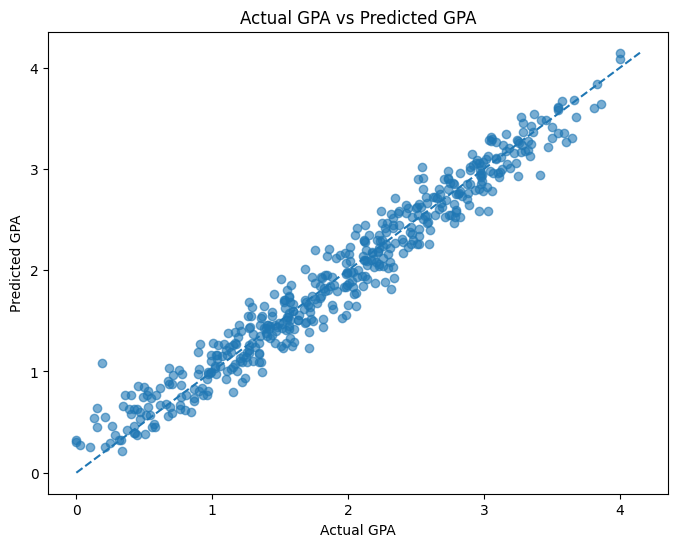

In [71]:

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_multi,
    alpha=0.6
)

minimum = min(
    y_test.min(),
    y_pred_multi.min()
)

maximum = max(
    y_test.max(),
    y_pred_multi.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.title("Actual GPA vs Predicted GPA")
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")

plt.show()


# 47. Final Model Results

The final results of the regression experiments are summarized below.

The comparison includes:

- Univariate Regression from Scratch
- Univariate Regression using Scikit-Learn
- Multivariate Regression using Scikit-Learn

The main evaluation metrics are:

- MAE
- RMSE
- R²

All model comparisons are based on test-set performance.

---

In [72]:

# Final results table

final_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²"
    ],
    
    "Univariate Scratch": [
        mae_scratch,
        rmse_scratch,
        r2_scratch
    ],
    
    "Univariate Scikit-Learn": [
        mae_sklearn_uni,
        rmse_sklearn_uni,
        r2_sklearn_uni
    ],
    
    "Multivariate Scikit-Learn": [
        mae_multi,
        rmse_multi,
        r2_multi
    ]
})

final_results


,Metric,Univariate Scratch,Univariate Scikit-Learn,Multivariate Scikit-Learn
0,MAE,0.762568,0.762568,0.150918
1,RMSE,0.905951,0.905951,0.189147
2,R²,0.007481,0.007481,0.956736


# 48. Final Findings

The following findings are based on the actual experiments performed in this
project.

### Dataset

The Student Performance Dataset contains academic, demographic, and
behavioural information about students.

### Data Cleaning

The dataset was checked for missing values, duplicate records, data types,
and potential numerical outliers.

### EDA

Exploratory analysis was used to investigate relationships between student
features and GPA.

### Univariate Regression

StudyTimeWeekly was selected as the single numerical feature for the
from-scratch regression model.

### Gradient Descent

Batch Gradient Descent was implemented manually using NumPy.

### Learning Rate

Three learning rates were compared to study their effect on convergence.

### Feature Scaling

Standardisation was applied to demonstrate how feature scaling affects
Gradient Descent.

### Multivariate Regression

Multiple numerical and categorical features were used in the Scikit-Learn
Linear Regression model.

### Evaluation

The models were evaluated using MAE, RMSE, and R².

### Model Comparison

The models were compared using test-set RMSE and R².

### Coefficient Analysis

Regression coefficients were examined to understand positive and negative
associations with predicted GPA.

### Residual Analysis

Residual plots and a residual histogram were used to investigate model
errors and Linear Regression assumptions.

---

# 49. Key Findings

## Finding 1 — EDA

The EDA showed that ______________________________________________.

## Finding 2 — Study Time

The relationship between StudyTimeWeekly and GPA appeared
______________________________________________.

## Finding 3 — Absences

The relationship between Absences and GPA appeared
______________________________________________.

## Finding 4 — Gradient Descent

The most suitable learning rate among those tested was
______________________________________________ because
______________________________________________.

## Finding 5 — Feature Scaling

Feature scaling ______________________________________________ Gradient
Descent convergence.

## Finding 6 — Model Performance

The best-performing model based on test RMSE was
______________________________________________.

Its RMSE was __________________ and its R² was __________________.

## Finding 7 — Categorical Features

Adding categorical features ______________________________________________
the model performance.

## Finding 8 — Residuals

The residual analysis showed ______________________________________________.

---

# 50. Limitations

This project has several limitations.

1. The model uses only the variables available in the selected dataset.
   Other factors that influence academic performance may not be recorded.

2. Linear Regression assumes a relatively linear relationship between the
   predictors and GPA. Student performance may involve more complex
   relationships.

3. The dataset may not represent every student population, institution, or
   educational environment.

4. Categorical and demographic variables may contain information that does
   not generalize to other populations.

5. The model identifies statistical relationships rather than proving
   causation.

6. The model is evaluated using one train-test split, so different samples
   could produce somewhat different results.

7. GPA prediction should therefore be treated as an approximate prediction
   task rather than a perfectly precise determination of student performance.


---

# 51. Conclusion

This project demonstrated a complete Machine Learning regression workflow for
predicting student GPA.

The project started with understanding and cleaning the Student Performance
Dataset. Missing values, duplicate records, data types, and potential
outliers were examined before model development.

Exploratory Data Analysis was then performed to understand relationships
between student characteristics and GPA. StudyTimeWeekly was selected as the
main numerical feature for the univariate regression experiment.

A Linear Regression model was implemented from scratch using NumPy. The
Mean Squared Error cost function and Batch Gradient Descent algorithm were
implemented manually. Different learning rates were tested to understand
their effect on model convergence.

Feature scaling was then applied to StudyTimeWeekly and the scaled and
unscaled Gradient Descent behaviour was compared.

A multivariate Linear Regression model was subsequently developed using
Scikit-Learn. Multiple numerical features and useful categorical features
were included, with numerical features standardized and categorical features
converted using One-Hot Encoding.

The models were evaluated using Mean Absolute Error, Root Mean Squared Error,
and R². The univariate scratch model, univariate Scikit-Learn model, and
multivariate Scikit-Learn model were compared using their test-set
performance.

Regression coefficients were analysed to understand the direction of
associations between features and predicted GPA. Finally, residual analysis
was performed using a residual-versus-predicted plot and residual histogram
to investigate model errors and regression assumptions.

Overall, this project provided practical understanding of how a real-world
student performance dataset can be transformed into a regression solution.
It demonstrated the complete workflow from raw data to prediction,
evaluation, interpretation, and conclusion.

The final conclusions are based on the actual results produced by the
experiments in this notebook. The model should be considered an approximate
prediction tool, and the statistical relationships identified by the model
should not be interpreted as proof of causal relationships.

This conclusion covers the learning outcomes specified by the assignment, including regression, Gradient Descent, scaling, evaluation, coefficient interpretation, residual analysis, and limitations. 

---

# 52. Final Project Summary

## Machine Learning Workflow Completed

| Stage | Completed |
|---|---|
| Dataset Loading | ✓ |
| Data Understanding | ✓ |
| Missing Value Check | ✓ |
| Duplicate Check | ✓ |
| Outlier Analysis | ✓ |
| Data Cleaning | ✓ |
| Exploratory Data Analysis | ✓ |
| Feature Engineering | ✓ |
| Univariate Regression | ✓ |
| MSE from Scratch | ✓ |
| Batch Gradient Descent | ✓ |
| Learning Rate Experiment | ✓ |
| Feature Scaling | ✓ |
| Scaled vs Unscaled Comparison | ✓ |
| Scikit-Learn Univariate Regression | ✓ |
| Multivariate Regression | ✓ |
| One-Hot Encoding | ✓ |
| Train-Test Split | ✓ |
| MAE | ✓ |
| RMSE | ✓ |
| R² | ✓ |
| Coefficient Analysis | ✓ |
| Model Comparison | ✓ |
| Feature Contribution Analysis | ✓ |
| Residual Analysis | ✓ |
| Residual Histogram | ✓ |
| Regression Assumption Analysis | ✓ |
| Limitations | ✓ |
| Conclusion | ✓ |

# 48–51. Automated Final Findings, Limitations and Conclusion

The cells below convert the experimental outputs into submission-ready findings using the actual
values produced by the notebook. No metric or coefficient is fabricated before execution.

The project follows the required workflow: data cleaning, EDA, feature engineering, regression from
scratch, Batch Gradient Descent, learning-rate comparison, feature scaling, Scikit-Learn regression,
evaluation, coefficient analysis, model comparison, feature contribution analysis, residual analysis,
limitations, and conclusion. 


In [73]:
# Automated final findings based on actual notebook results

best_idx = comparison_table["Test RMSE"].idxmin()
best_row = comparison_table.loc[best_idx]

cat_improved = (rmse_B < rmse_A) and (r2_B > r2_A)

residual_mean = float(residuals.mean())
residual_std = float(residuals.std())

study_corr = correlation_matrix["GPA"].get(study_col, np.nan)
absence_corr = correlation_matrix["GPA"].get(absence_col, np.nan) if 'absence_col' in globals() else np.nan

print("KEY FINDINGS")
print("=" * 70)
print(f"Study-time vs GPA correlation: {study_corr:.4f}")
print(f"Absences vs GPA correlation: {absence_corr:.4f}")
print(f"Best model by test RMSE: {best_row['Model']}")
print(f"Best model test RMSE: {best_row['Test RMSE']:.4f}")
print(f"Best model test R²: {best_row['Test R²']:.4f}")
print(f"Model A RMSE: {rmse_A:.4f}")
print(f"Model B RMSE: {rmse_B:.4f}")
print(f"Model A R²: {r2_A:.4f}")
print(f"Model B R²: {r2_B:.4f}")
print(f"Categorical features improved both RMSE and R²: {cat_improved}")
print(f"Residual mean: {residual_mean:.4f}")
print(f"Residual standard deviation: {residual_std:.4f}")

print("\nTOP 3 COEFFICIENTS BY ABSOLUTE MAGNITUDE")
print(coefficient_df.sort_values("AbsoluteCoefficient", ascending=False).head(3)[["Feature", "Coefficient"]].to_string(index=False))

KEY FINDINGS
Study-time vs GPA correlation: 0.1793
Absences vs GPA correlation: -0.9193
Best model by test RMSE: Multivariate - Scikit-Learn
Best model test RMSE: 0.1891
Best model test R²: 0.9567
Model A RMSE: 0.1889
Model B RMSE: 0.1891
Model A R²: 0.9568
Model B R²: 0.9567
Categorical features improved both RMSE and R²: False
Residual mean: -0.0005
Residual standard deviation: 0.1893

TOP 3 COEFFICIENTS BY ABSOLUTE MAGNITUDE
                   Feature  Coefficient
       numerical__Absences    -0.789155
numerical__StudyTimeWeekly     0.163833
numerical__ParentalSupport     0.155651


## Submission-Ready Findings

After running all cells, use the printed values above as the factual basis for the final CA1 discussion.
The interpretation should remain descriptive: coefficients and correlations indicate statistical
associations in this dataset and do not prove causation.

### Regression Assumption Discussion

The residual-versus-predicted plot should be checked for curvature, clustering, systematic patterns,
and changing spread. The residual histogram should be checked for approximate symmetry around zero,
skewness, and extreme observations. If the residuals are randomly scattered around zero with roughly
constant spread and the histogram is reasonably symmetric, the Linear Regression assumptions appear
more reasonable; otherwise, the identified pattern should be reported as a limitation.

### Limitations

1. The model uses only the variables available in the selected dataset.
2. Linear Regression assumes a relatively linear relationship between predictors and GPA.
3. The dataset may not represent every student population or educational environment.
4. Demographic and categorical relationships may not generalize to other populations.
5. Model associations should not be interpreted as causal relationships.
6. Results depend on the chosen train-test split.
7. GPA prediction should therefore be treated as an approximate prediction task.

### Conclusion

This project demonstrated a complete Machine Learning regression workflow for predicting student GPA.
The work covered data understanding and cleaning, Exploratory Data Analysis, feature engineering,
a NumPy implementation of Mean Squared Error and Batch Gradient Descent, learning-rate experiments,
feature scaling, Scikit-Learn univariate and multivariate Linear Regression, categorical encoding,
evaluation using MAE/RMSE/R², coefficient analysis, model comparison, feature contribution analysis,
and residual analysis.

The final model choice is determined from the actual test-set RMSE and R² values generated by the
notebook. The results should be interpreted as evidence of predictive performance on the selected
dataset rather than proof of causal relationships. 